In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline


# Função para treinar e avaliar o modelo em cada arquivo
def train_and_evaluate(csv_path):
    try:
        df = pd.read_csv(csv_path)
        imputer = SimpleImputer(strategy='mean')
        df_imputed = pd.DataFrame(imputer.fit_transform(df), columns=df.columns)
        
        y = df_imputed['Aprovou_Aprovou']
        X = df_imputed.drop('Aprovou_Aprovou', axis=1)
        
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        model_pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('logistic_regression', LogisticRegression())
        ])
        
        model_pipeline.fit(X_train, y_train)
        y_pred = model_pipeline.predict(X_test)
        
        print(f"Resultados para {csv_path}:")
        print("Acurácia:", accuracy_score(y_test, y_pred))
        print("Relatório de Classificação:\n", classification_report(y_test, y_pred))
    
    except FileNotFoundError:
        print(f"ERRO: O arquivo '{csv_path}' não foi encontrado.")
    except KeyError:
        print(f"ERRO: A coluna 'Aprovou_Aprovou' não foi encontrada no arquivo '{csv_path}'.")
    except Exception as e:
        print(f"ERRO inesperado ao processar '{csv_path}': {e}")
    
    print("-" * 50)


In [ ]:
train_and_evaluate('dados/dados_modelo1.csv')

Resultados para dados/dados_modelo1.csv:
Acurácia: 0.9672727272727273
Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.58      0.64      0.61        11
         1.0       0.98      0.98      0.98       264

    accuracy                           0.97       275
   macro avg       0.78      0.81      0.80       275
weighted avg       0.97      0.97      0.97       275

--------------------------------------------------


In [ ]:
train_and_evaluate('dados/dados_modelo2.csv')

Resultados para dados/dados_modelo2.csv:
Acurácia: 0.9636363636363636
Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.55      0.55      0.55        11
         1.0       0.98      0.98      0.98       264

    accuracy                           0.96       275
   macro avg       0.76      0.76      0.76       275
weighted avg       0.96      0.96      0.96       275

--------------------------------------------------


In [ ]:
train_and_evaluate('dados/dados_modelo3.csv')

Resultados para dados/dados_modelo3.csv:
Acurácia: 0.9745454545454545
Relatório de Classificação:
               precision    recall  f1-score   support

         0.0       0.67      0.73      0.70        11
         1.0       0.99      0.98      0.99       264

    accuracy                           0.97       275
   macro avg       0.83      0.86      0.84       275
weighted avg       0.98      0.97      0.98       275

--------------------------------------------------


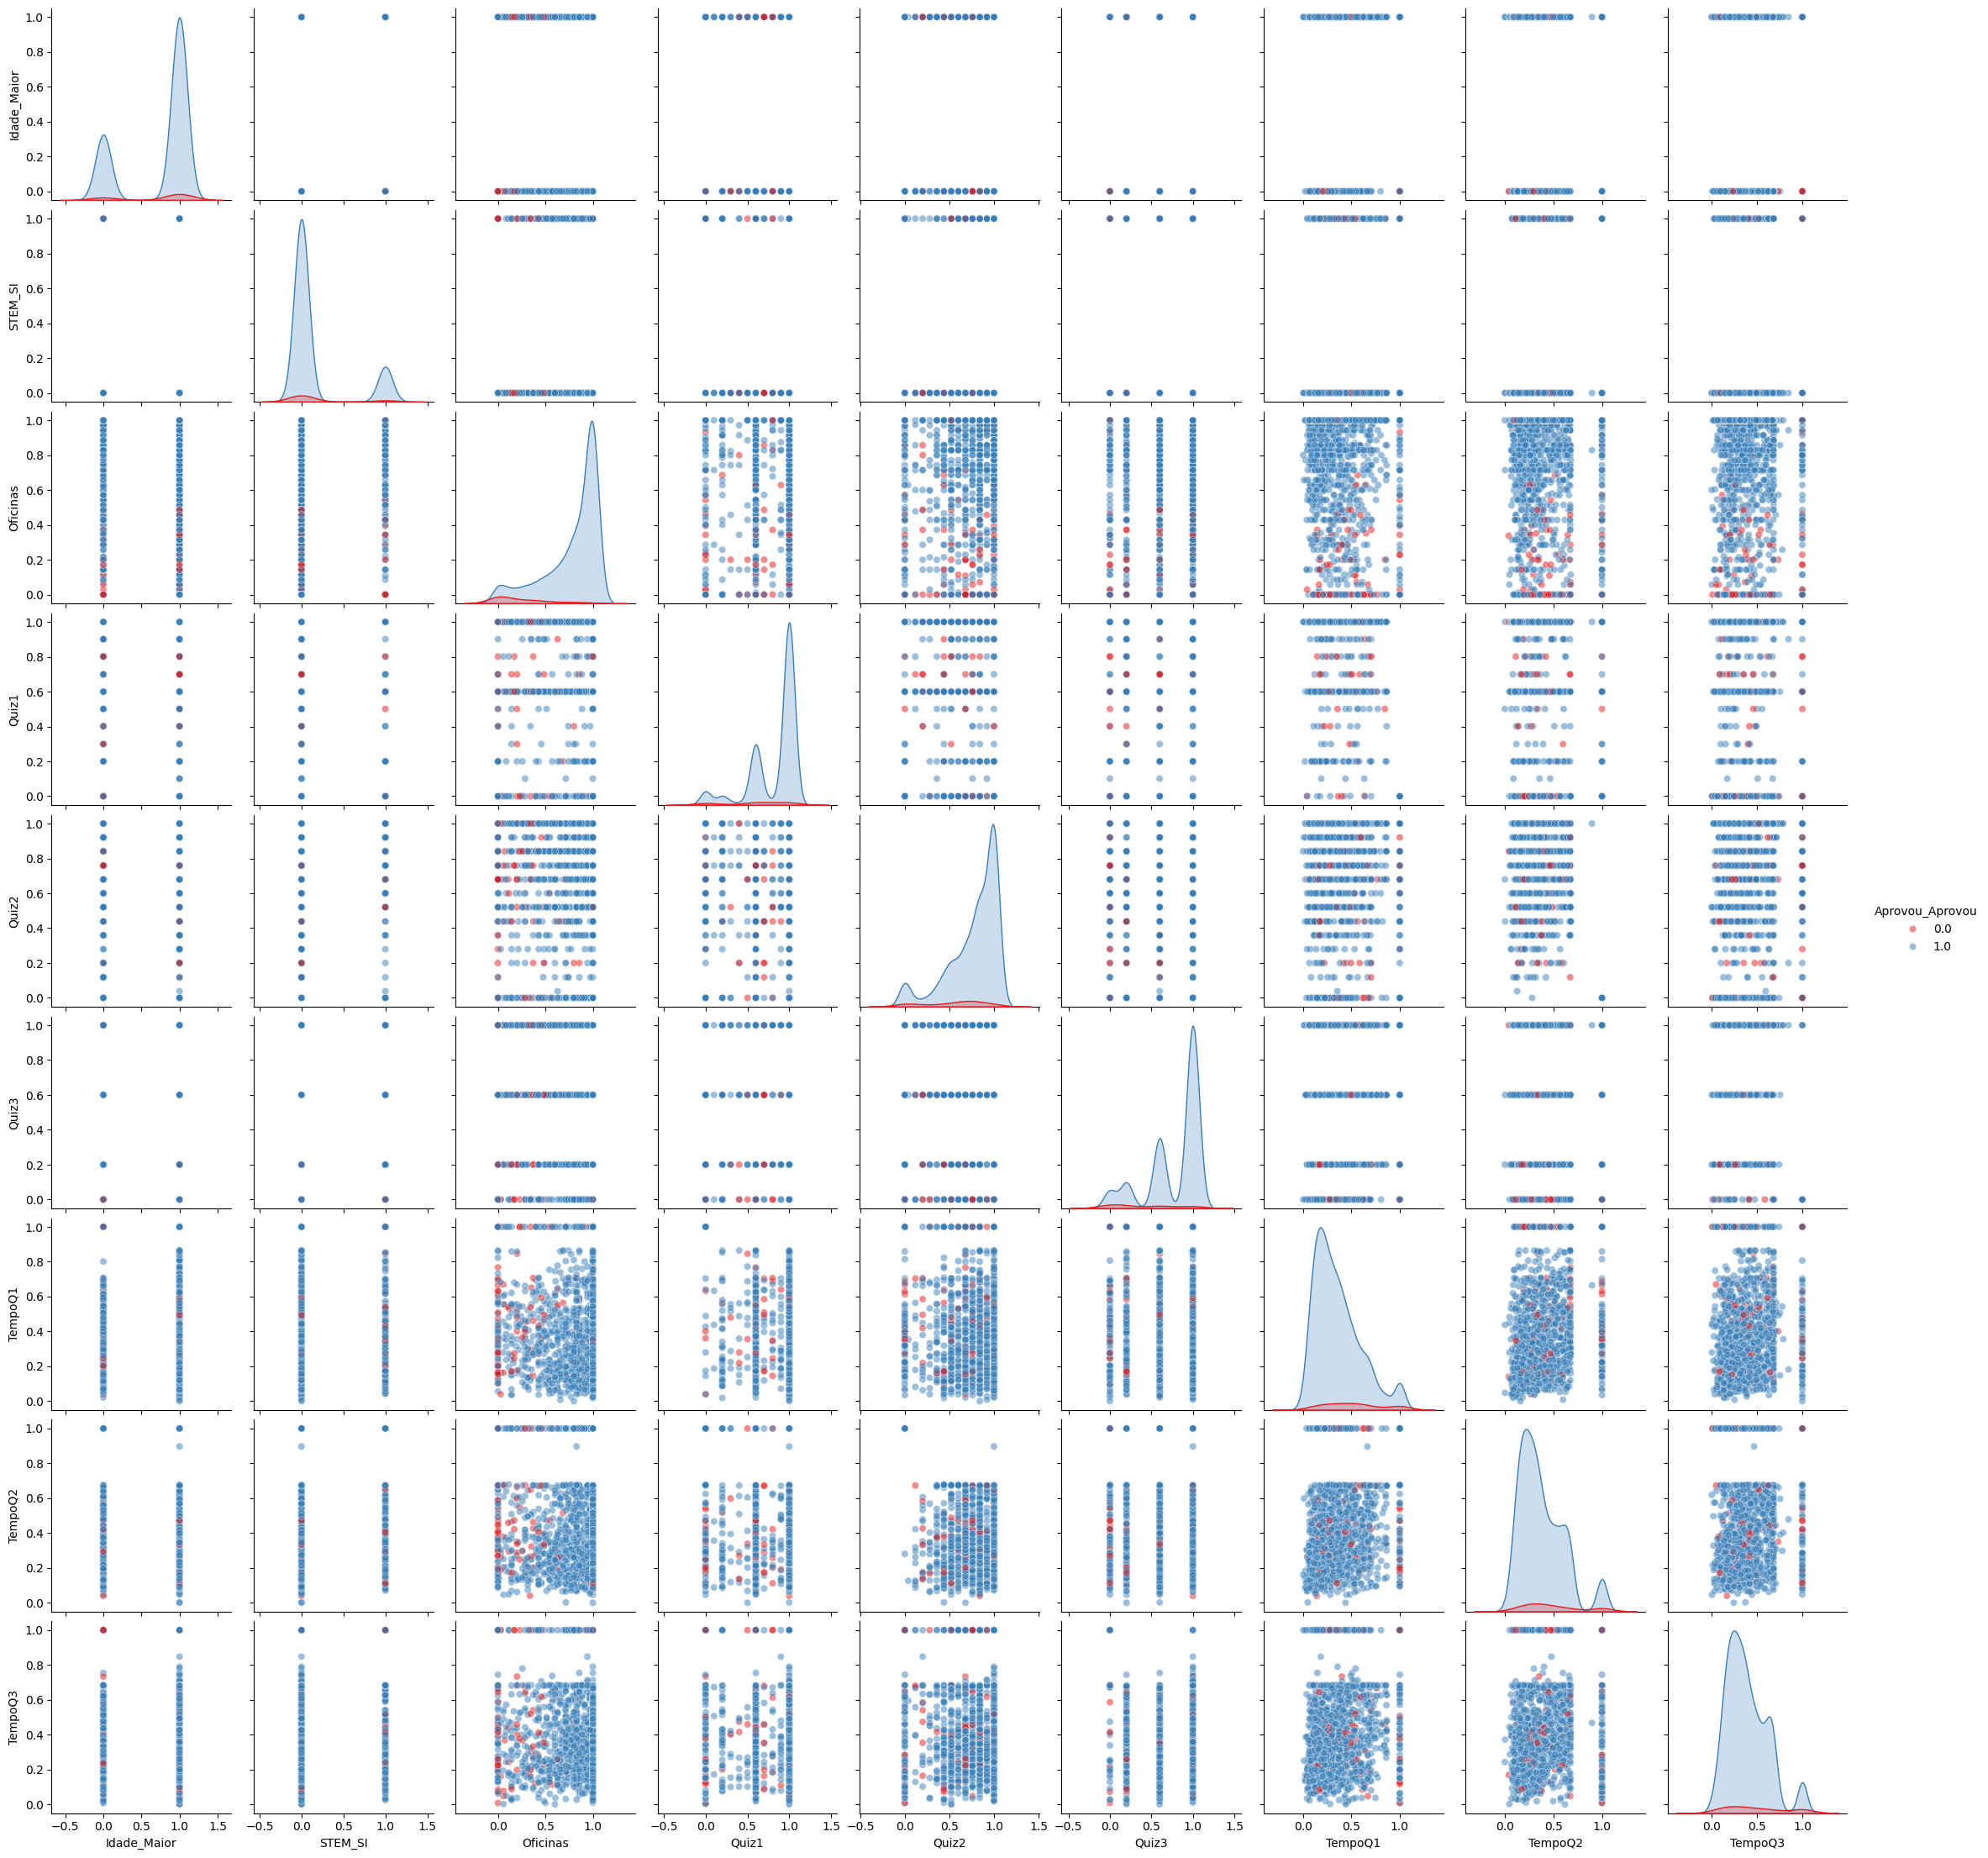